# eBOSS post-starburst analysis

In this second notebook, we visualze results from our post-starburst galaxy selection methods outlined in `01_eBOSS_classification.ipynb`. 

In [1]:
import numpy as np                                # to do math
import matplotlib.pyplot as plt                   # plotting functions
import pandas as pd                               # table format
import os                                         # universal os
from astroquery.sdss import SDSS                  # to query SDSS spectra
import astropy.units as u                         # convenient unit conversion

## Loading data

In [2]:
data_folder_name = 'classified_sample'  
filename = 'classified_eBOSS_sample.csv'  # subsample we previously generated from the eBOSS parent sample

# accessing file from current directory
file_path = os.path.join('..', data_folder_name, filename)
file_path

'../classified_sample/classified_eBOSS_sample.csv'

In [3]:
# opening the .csv file as a DataFrame
classified_eBOSS_sample = pd.read_csv(file_path)
classified_eBOSS_sample

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
0,3586,55181,452,03586-55181-0452,0.059661,0.000007,6.782106,-0.839099,38.867240,6.734732,1.308583,0.015106,4.999078,0.442007,1.992465,0.033930,S,starburst
1,3586,55181,472,03586-55181-0472,0.046088,0.000013,6.989973,-0.061284,23.616392,4.084003,1.352124,0.006651,4.078517,0.176159,1.918211,0.012858,L,starburst
2,3587,55182,24,03587-55182-0024,0.238845,0.000008,10.303943,-0.340399,67.070630,13.497214,1.220295,0.014409,5.621124,0.484673,1.923127,0.028568,S,starburst
3,3587,55182,123,03587-55182-0123,0.079434,0.000011,9.775995,-0.640401,43.130123,9.079031,1.204624,0.017098,5.766086,0.539461,1.726129,0.033379,S,starburst
4,3587,55182,148,03587-55182-0148,0.044899,0.000008,9.611146,-0.011863,85.787920,13.813966,1.213467,0.004138,6.227307,0.125825,1.909761,0.008919,C,starburst
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3914,12527,58930,539,12527-58930-0539,0.102777,0.000013,128.798653,1.814807,24.956808,5.327566,1.181456,0.008618,4.044683,0.286081,1.682566,0.015436,C,starburst
3915,12527,58930,558,12527-58930-0558,0.031694,0.000011,129.348318,1.857523,33.370937,7.316120,1.176211,0.012392,6.044748,0.368935,1.527946,0.024071,S,starburst
3916,12544,58928,619,12544-58928-0619,0.139711,0.000018,137.491416,2.422952,18.768353,4.196416,1.386433,0.018590,5.208617,0.456687,2.078570,0.032782,S,starburst
3917,12545,58930,4,12545-58930-0004,0.158808,0.000009,141.381060,-0.988900,54.811554,12.027341,1.176203,0.011414,6.264442,0.374673,1.769086,0.020212,S,starburst


## Redshift distribution of sample

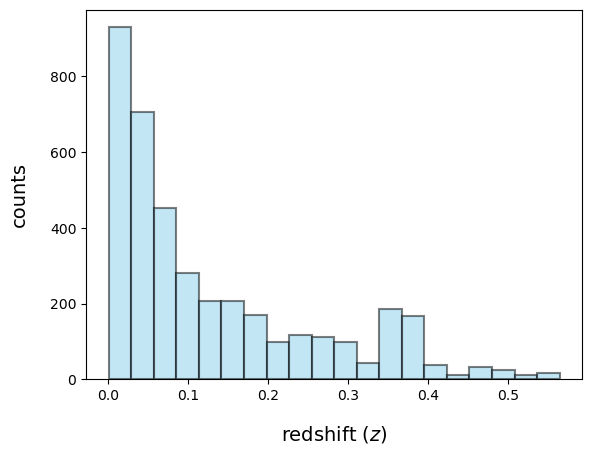

In [4]:
# initializing our figure
plt.figure()

# plotting data in a histogram
x_values = classified_eBOSS_sample['Z']
plt.hist(x_values, bins=20, alpha=0.5, color='skyblue', edgecolor='k', linewidth=1.5)

# labeling our axes
plt.xlabel(r'redshift ($z$)', fontsize=14, labelpad=15)
plt.ylabel('counts', fontsize=14, labelpad=15)

# saving and displaying figure
fig_name = 'redshift_distribution.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Our sample consists of galaxies at $\, z\sim0-0.5$

## Visualizing our sample classifications

To make plotting simpler, we will split up our sample by post-starburst classification and save them in a dictionary

In [5]:
# splitting up our dataframe into these classifications
non_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='starburst']
classic_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='classic PSB']
young_psb_sample = classified_eBOSS_sample[classified_eBOSS_sample['PSB_CLASS']=='young PSB']

# and saving as a dictionary
sample_dict = {'starburst': non_psb_sample, 'classic PSB': classic_psb_sample, 'young PSB': young_psb_sample}
color_dict = {'starburst': '#2995ff', 'classic PSB': '#ffb327', 'young PSB': '#55d655'}  # mapping colors for plotting

Let's compute the classification percentages for our sample

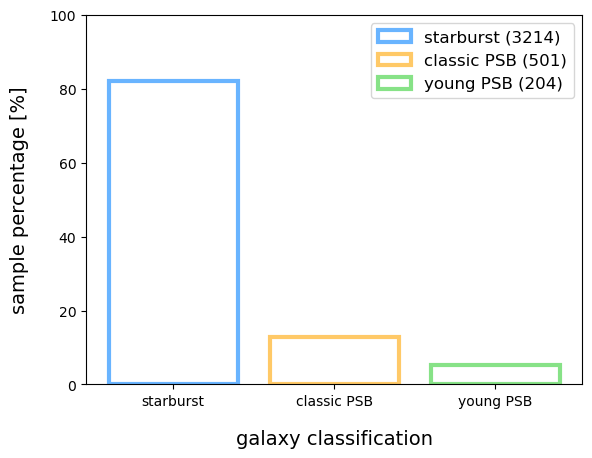

In [6]:
# initializing our figure
plt.figure()

labels = []
for i, key in enumerate(sample_dict):

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]
    data_label = key+f' ({len(subsample_data)})'

    # computing percentage
    counts = len(subsample_data)
    total = len(classified_eBOSS_sample)
    perc = 100 * counts / total

    # plotting data in a bar plot
    x_values = i     # given index of classification (0,1,2)
    y_values = perc  # associated percentage
    plt.bar(x_values, y_values, alpha=0.7, facecolor='none', edgecolor=subsample_color, linewidth=3, label=data_label)

# adding tick labels
labels = list(sample_dict.keys())
positions = np.arange(len(labels))
plt.xticks(positions, labels)

# scaling y-axis
plt.ylim(0,100)

# labeling our axes
plt.xlabel('galaxy classification', fontsize=14, labelpad=15)
plt.ylabel('sample percentage [%]', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'classification_distribution.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

## Visualizing Spectral Properties of Sample

### Past SFR vs recent SFR

We can probe different timescales of star-formation using the relationship between $H\alpha$ equivalent width and $H\delta_A$. Both of these measurements probe star formation on $\sim10$ Myr and $\sim1$ Gyr timescales, respectively.

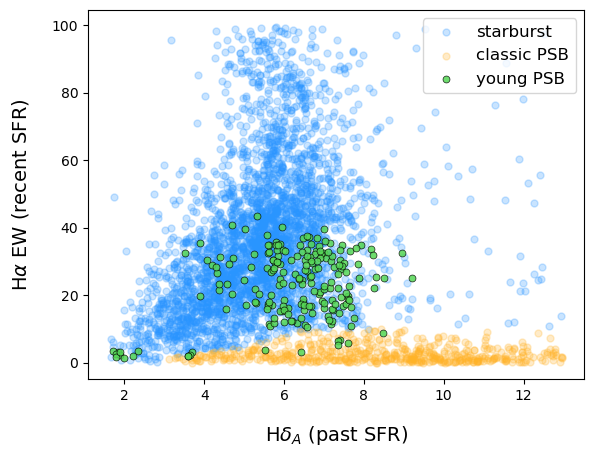

In [7]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['LICK_HDA']
    y_values = subsample_data['H_ALPHA_EW']
    if key == "young PSB":
        plt.scatter(x_values, y_values, s=25, alpha=0.85, c=subsample_color, edgecolors='black', linewidths=0.5,label=key)

    else:
        plt.scatter(x_values, y_values, s=25, alpha=0.25, c=subsample_color, label=key)

# labeling our axes
plt.xlabel(r'H$\delta_{A}$ (past SFR)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\alpha$ EW (recent SFR)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'H_delta_vs_H_alpha.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Post-starbursts are theorized to lie in the bottom right corner of this diagram. These galaxies exhibit a lower $H\alpha$ nebular emission than expected for the strength of their Balmer absorption lines (i.e., $H\delta$). This selection allows us to include galaxies in the process of shutting down their SF. Below, I show this diagram taken from the literature (French+2016). 

<img src="../plots/French+2016_presentation_slide.png" width="600">

### Stellar population age

Next, we will look at the "Balmer Break" and the "4000 Å Break" measurements in galaxy spectra. 

These measurements probe the **temperature of stars** in a galaxy. According to the Hertzsprung-Russell Diagram, a star's temperature is correlated with its spectral type (i.e., O, B, A, ... etc.). Given a newly-formed population of stars, there will be a distribution of spectral types. After the stellar population has aged $\sim 10$ Myrs, the hotter/bluer stars (O and B stars) will die off before the cooler/redder stars. This will change the shape of the spectrum of the stellar population. Thus, the mean age of stellar populations in a galaxy can be determined by spectral features (e.g., the Balmer and 4000 Å Breaks) that trace any absence of young/hot/blue stars. 

Below are a handful of relationships using these breaks that will be useful to look at.

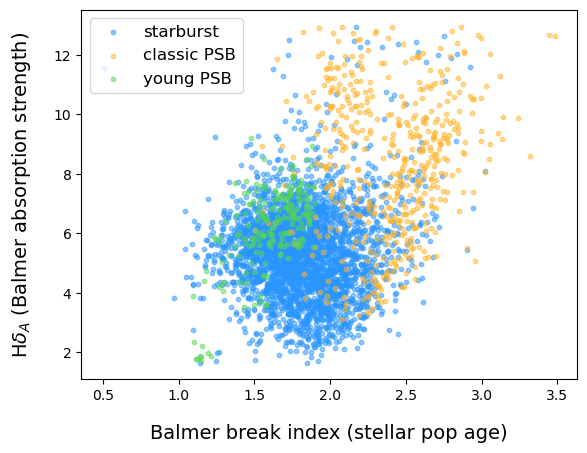

In [8]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['BALMERBREAK']
    y_values = subsample_data['LICK_HDA']
    
    plt.scatter(x_values, y_values, s=10, alpha=0.5, color=subsample_color, label=key)

# labeling our axes
plt.xlabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\delta_{A}$ (Balmer absorption strength)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper left')

# saving and displaying figure
fig_name = 'BalmerBreak_vs_H_delta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

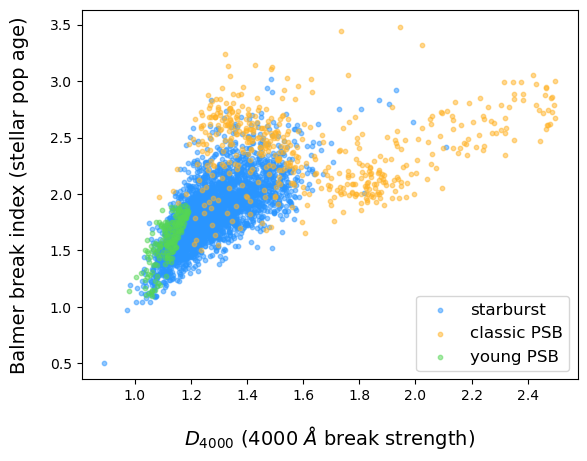

In [9]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['D_4000']
    y_values = subsample_data['BALMERBREAK']
    plt.scatter(x_values, y_values, s=10, alpha=0.5, color=subsample_color, label=key)

# labeling our axes
plt.xlabel(r'$D_{4000}$ (4000 $\AA$ break strength)', fontsize=14, labelpad=15)
plt.ylabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='lower right')

# saving and displaying figure
fig_name = 'D_4000_vs_BalmerBreak.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

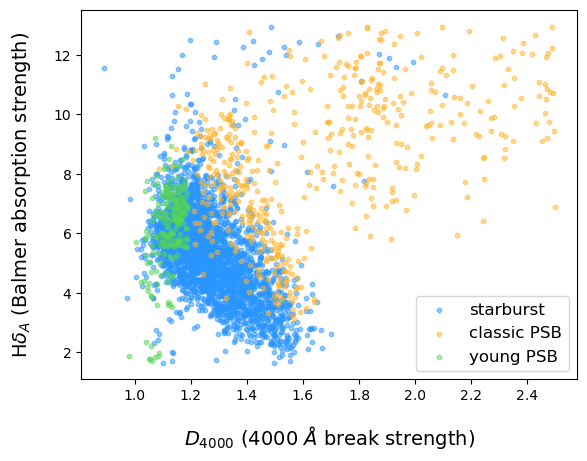

In [10]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['D_4000']
    y_values = subsample_data['LICK_HDA']
    plt.scatter(x_values, y_values, s=10, alpha=0.5, color=subsample_color, label=key)

# labeling our axes
plt.xlabel(r'$D_{4000}$ (4000 $\AA$ break strength)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\delta_{A}$ (Balmer absorption strength)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='lower right')

# saving and displaying figure
fig_name = 'D_4000_vs_H_delta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

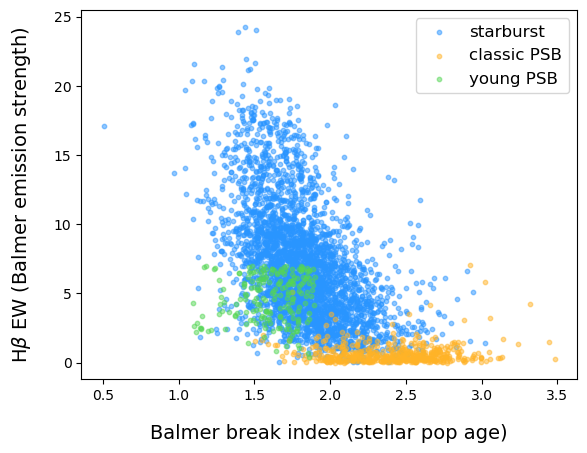

In [11]:
# initializing our figure
plt.figure()

for key in sample_dict:

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a scatter plot
    x_values = subsample_data['BALMERBREAK']
    y_values = subsample_data['H_BETA_EW']
    plt.scatter(x_values, y_values, s=10, alpha=0.5, color=subsample_color, label=key)

# labeling our axes
plt.xlabel('Balmer break index (stellar pop age)', fontsize=14, labelpad=15)
plt.ylabel(r'H$\beta$ EW (Balmer emission strength)', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'BalmerBreak_vs_H_beta.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

### BPT diagram

This diagram classifies galaxies based on their inferred ionization source (the thing that is causing the emission that we measure). The eBOSS catalog has already classified galaxies on this diagram. So, we can take note of these classifications for our post-starbursts.

In [12]:
classified_eBOSS_sample['BPT_CLASS'].value_counts()

BPT_CLASS
S    2587
U     438
L     417
C     361
A     116
Name: count, dtype: int64

As shown above, these classifications include:
- `U` --> Unclassified ?
- `S` --> Star-forming ?
- `L` --> Liner ?
- `C` --> Composite ?
- `A` --> AGN ?

Let's see the number of galaxies in each classification for our sub-samples

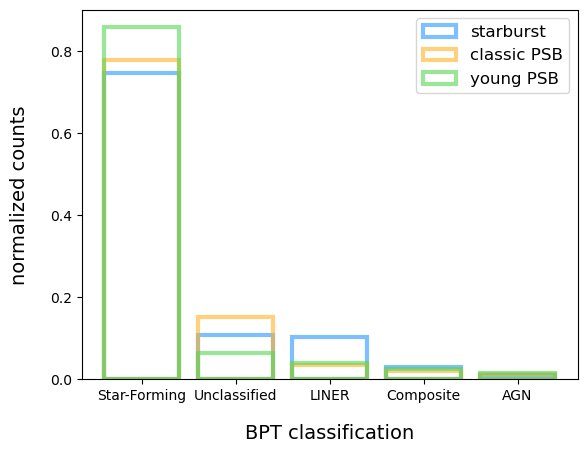

In [13]:
# initializing our figure
plt.figure()

for i, key in enumerate(sample_dict):

    # retrieving sub-sample with key
    subsample_data = sample_dict[key]
    subsample_color = color_dict[key]

    # plotting data in a NORMALIZED bar plot
    y_values = subsample_data['BPT_CLASS'].value_counts(normalize=True)
    x_values = np.arange(len(y_values)) 
    
    plt.bar(x_values, y_values, alpha=0.6, facecolor='none', edgecolor=subsample_color, linewidth=3, label=key)

# adding tick labels
labels = ['Star-Forming', 'Unclassified', 'LINER', 'Composite', 'AGN']
positions = np.arange(len(labels))
plt.xticks(positions, labels)

# labeling our axes
plt.xlabel('BPT classification', fontsize=14, labelpad=15)
plt.ylabel('normalized counts', fontsize=14, labelpad=15)
plt.legend(fontsize=12, loc='upper right')

# saving and displaying figure
fig_name = 'BPT_classification.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Below, we show where post-starbursts usually exist within the BPT classification scheme (French+2015). The "Seyferts" region contains galaxies with AGN. Post-starbursts exist everywhere except for the star-forming region, but primarily within the LINER region.

<img src="../plots/French+2015_figure.png" width="600">

## Spectra for galaxies in our sample

To obtain archival SDSS spectra, we will query the data using `astroquery`.

To pick a spectrum at random, we display a small range of galaxies for each classification. The range can be adjusted (i.e., `.iloc[0:10]`, `.iloc[10:20]`, `.iloc[20:30]`, etc...)

In [14]:
young_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
81,3647,55181,364,03647-55181-0364,0.108189,0.000020,36.636760,-1.218301,22.136515,5.327466,1.146725,0.013745,7.146050,0.414954,1.533671,0.026846,S,young PSB
143,3670,55480,738,03670-55480-0738,0.013786,0.000017,116.721994,39.005052,21.533379,4.354599,1.021334,0.007659,4.373318,0.295237,1.302378,0.015780,S,young PSB
144,3672,55484,540,03672-55484-0540,0.019360,0.000015,116.099425,40.342342,30.547796,5.214518,1.164529,0.014413,6.516558,0.461418,1.792031,0.039312,S,young PSB
167,3692,55186,475,03692-55186-0475,0.007584,0.000018,122.784630,46.465649,17.232460,3.527752,1.003763,0.004643,5.698599,0.171640,1.266298,0.010030,S,young PSB
174,3736,55214,384,03736-55214-0384,0.487584,0.000077,16.419830,-0.553872,3.179743,3.890871,1.117821,0.005320,3.699385,0.193321,1.539888,0.007432,U,young PSB
196,3774,55244,498,03774-55244-0498,0.024391,0.000017,169.477090,-2.088718,30.958498,6.989200,1.077535,0.012397,4.731013,0.422065,1.181236,0.021261,S,young PSB
203,3785,55241,821,03785-55241-0821,0.316467,0.000015,158.038166,-1.500396,29.023060,5.983720,1.044708,0.008084,4.202374,0.326833,1.264997,0.010431,S,young PSB
207,3785,55273,807,03785-55273-0807,0.316453,0.000015,158.038166,-1.500396,30.470057,5.300985,1.046269,0.008079,4.072718,0.326098,1.291609,0.010734,S,young PSB
210,3793,55214,832,03793-55214-0832,0.005285,0.000025,191.381455,-0.540018,17.397472,3.399538,1.063555,0.007769,5.602722,0.275187,1.372356,0.018448,S,young PSB
238,3841,56016,890,03841-56016-0890,0.028611,0.000016,175.997494,0.429144,33.368492,6.422952,1.106580,0.010083,6.563181,0.338414,1.693253,0.025328,S,young PSB


In [15]:
classic_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
7,3587,55182,766,03587-55182-0766,0.013850,0.000062,9.132152,0.563281,7.500078,1.653817,1.273995,0.019915,6.042478,0.531182,1.726371,0.056440,S,classic PSB
38,3615,55179,962,03615-55179-0962,0.367720,0.000046,38.256082,0.461005,0.568509,0.348130,2.242338,0.047818,6.419164,0.522504,2.394710,0.051487,U,classic PSB
45,3615,55208,555,03615-55208-0555,0.391636,0.000120,36.150345,1.034750,1.887370,0.430450,1.337789,0.032270,9.816565,0.657004,2.763852,0.078619,U,classic PSB
46,3615,55208,574,03615-55208-0574,0.267958,0.000028,36.285573,0.395360,1.072568,0.083579,1.563180,0.014698,3.460790,0.325508,2.100727,0.023829,U,classic PSB
55,3615,55445,547,03615-55445-0547,0.391610,0.000120,36.150345,1.034750,0.827186,0.645192,1.336224,0.024198,9.336852,0.758258,2.750350,0.068406,U,classic PSB
56,3615,55445,570,03615-55445-0570,0.268079,0.000030,36.285573,0.395360,1.393927,0.424319,1.640177,0.017511,3.793898,0.364734,2.313181,0.029234,U,classic PSB
62,3615,55856,543,03615-55856-0543,0.391901,0.000117,36.150345,1.034750,1.582105,0.779335,1.325444,0.026742,9.227488,0.834052,2.679901,0.071183,U,classic PSB
75,3615,56544,505,03615-56544-0505,0.391852,0.000129,36.150345,1.034750,0.209617,0.342146,1.484955,0.024393,9.369776,0.609053,3.107601,0.070151,U,classic PSB
91,3647,55241,545,03647-55241-0545,0.391439,0.000151,36.150345,1.034750,0.607672,0.422795,1.304206,0.031138,9.531018,0.891700,2.844433,0.092504,U,classic PSB
97,3647,55476,505,03647-55476-0505,0.391664,0.000208,36.150345,1.034750,1.986870,0.320953,1.489730,0.027074,11.285812,0.841519,3.121819,0.080964,U,classic PSB


In [16]:
non_psb_sample.iloc[0:10]

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,D_4000,D_4000_ERR,LICK_HDA,LICK_HDA_ERR,BALMERBREAK,BALMERBREAK_ERR,BPT_CLASS,PSB_CLASS
0,3586,55181,452,03586-55181-0452,0.059661,0.000007,6.782106,-0.839099,38.867240,6.734732,1.308583,0.015106,4.999078,0.442007,1.992465,0.033930,S,starburst
1,3586,55181,472,03586-55181-0472,0.046088,0.000013,6.989973,-0.061284,23.616392,4.084003,1.352124,0.006651,4.078517,0.176159,1.918211,0.012858,L,starburst
2,3587,55182,24,03587-55182-0024,0.238845,0.000008,10.303943,-0.340399,67.070630,13.497214,1.220295,0.014409,5.621124,0.484673,1.923127,0.028568,S,starburst
3,3587,55182,123,03587-55182-0123,0.079434,0.000011,9.775995,-0.640401,43.130123,9.079031,1.204624,0.017098,5.766086,0.539461,1.726129,0.033379,S,starburst
4,3587,55182,148,03587-55182-0148,0.044899,0.000008,9.611146,-0.011863,85.787920,13.813966,1.213467,0.004138,6.227307,0.125825,1.909761,0.008919,C,starburst
5,3587,55182,610,03587-55182-0610,0.059908,0.000020,8.375639,0.753410,22.340052,5.154306,1.194616,0.009500,5.091711,0.311403,1.763809,0.019672,S,starburst
6,3587,55182,682,03587-55182-0682,0.060554,0.000015,8.613247,0.504440,36.068897,7.640985,1.161492,0.008176,5.864232,0.274187,1.709834,0.016622,S,starburst
8,3587,55182,804,03587-55182-0804,0.214552,0.000015,9.433815,0.617476,38.383940,7.856672,1.198080,0.011488,6.303441,0.383738,1.766348,0.021062,S,starburst
9,3588,55184,340,03588-55184-0340,0.029947,0.000015,9.731443,-1.117875,28.342812,6.605982,1.239472,0.011486,6.148970,0.323875,1.699084,0.023917,S,starburst
10,3588,55184,445,03588-55184-0445,0.218994,0.000018,9.023457,-1.111678,56.801000,11.215842,1.175132,0.012923,6.700581,0.440397,1.812452,0.025170,S,starburst


A galaxy's identification (`PMF_STRING`) can be used to query its spectrum.

In [17]:
# saving a galaxy using its PMF_STRING
source = young_psb_sample[young_psb_sample['PMF_STRING'] == '03841-56016-0890'].iloc[0]

# saving relevant information from the columns in that row
plate = int(source['PLATE'])
mjd   = int(source['MJD'])
fiber = int(source['FIBER'])
key = source['PMF_STRING']
z = source['Z']
classification = source['PSB_CLASS']

# displaying the galaxy info:
print('galaxy identification:', key)
print('galaxy classification:', classification)

galaxy identification: 03841-56016-0890
galaxy classification: young PSB


In [18]:
# ... this cell might take a minute to run ...

# try to query spectra from SDSS archive
try:

    # query
    spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber)

    if spec is not None:

        hdu = spec[0]  # header-data unit (hdu)

        # ----------- saving spectral data ------------

        # flux
        flux_density_factor = hdu[1].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
        flux_density = 10**(-17) * flux_density_factor  # [ergs / s / cm^2 / A]

        # flux error
        ivar = hdu[1].data['ivar']
        flux_density_err = np.zeros_like(flux_density)
        good = ivar > 0    # avoid dividing by zero
        flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])

        # wavelength
        log_wav = hdu[1].data['loglam']
        wavelength = 10**log_wav         # [A]

        # ----------------------------------------------

        print('successfully saved galaxy spectrum')

# if unable to find spectra, give exception
except Exception as e:
    print(f"Failed to retrieve spectrum for {key}: {e}")


successfully saved galaxy spectrum


In [19]:
# convert spectrum from observed frame to rest frame using the object's redshift
rest_frame_wavelength = wavelength / (1+z)
rest_frame_flux_density = flux_density * (1+z)
rest_frame_flux_density_err = flux_density_err * (1+z)

Now, let's see the spectrum !

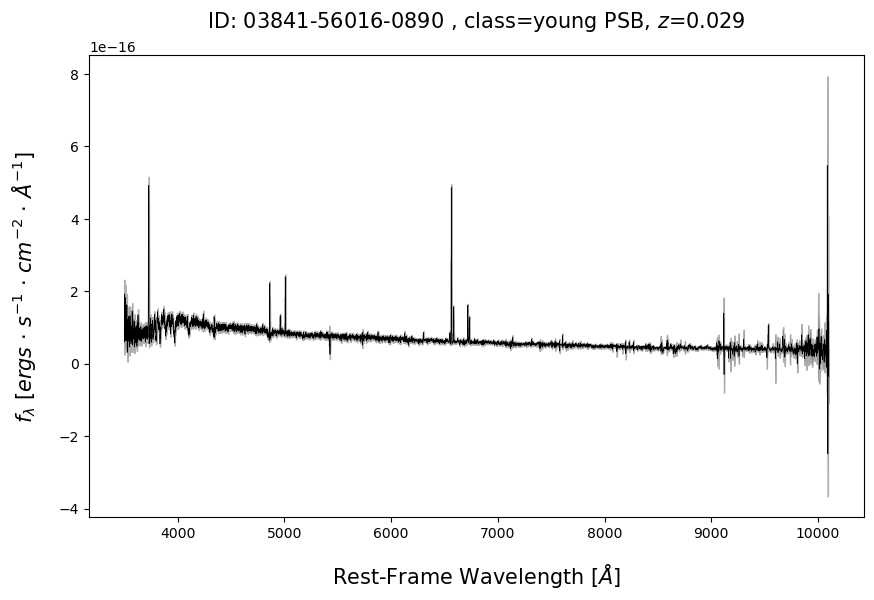

In [21]:
# initializing our figure
plt.figure(figsize=(10,6))

# labeling our axes
plt.title(f"ID: {key} , class={classification}, $z$={z:.3f}",fontsize=15, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# main spectral data
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.5)

# flux errors shown by shaded region
upper = rest_frame_flux_density + rest_frame_flux_density_err
lower = rest_frame_flux_density - rest_frame_flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.3)

# saving and displaying figure
fig_name = f'{key}_spectrum.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
# plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

We can zoom in a bit to make out any prominent spectral features

In [22]:
# compute the median flux value (which approximates the continuum level emission)
median_flux = np.median(rest_frame_flux_density)

# ~~~~~~~~~~~~~~ try updating the lower and upper factors ~~~~~~~~~~~~~~
lower_y_lim = median_flux * 0.25
upper_y_lim = median_flux * 3
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [23]:
# ~~~~~~~~~~ try with a different line or modify window size  ~~~~~~~~~~
spectral_feature = 'H-delta'          # name of the spectral feature
spectral_feature_wavelength = 4101    # rest-frame wavlength in Angstroms

lower_x_lim = spectral_feature_wavelength - 500   # create a window around the spectral feature
upper_x_lim = spectral_feature_wavelength + 500   # ''
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

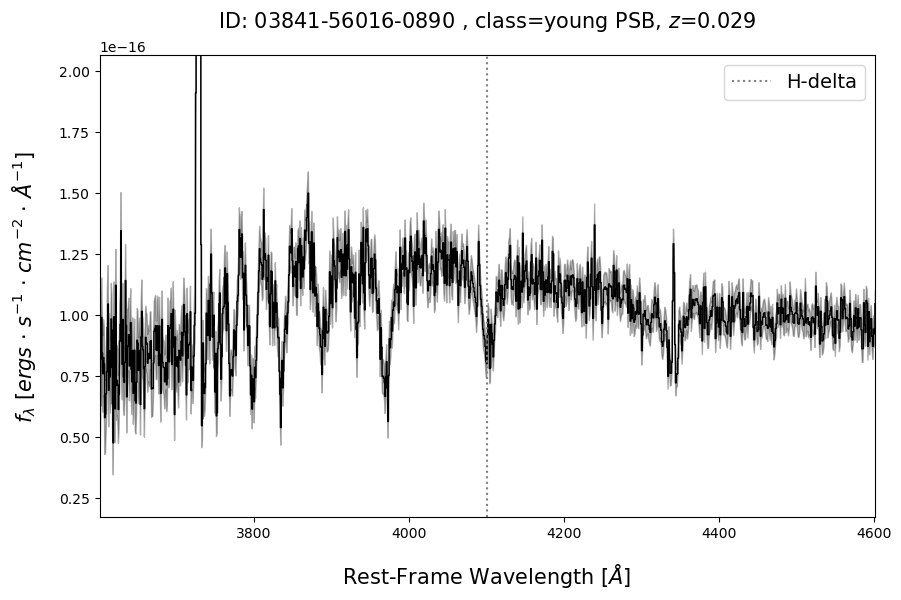

In [27]:
# initializing our figure
plt.figure(figsize=(10,6))

# labeling our axes
plt.title(f"ID: {key} , class={classification}, $z$={z:.3f}",fontsize=15, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# main spectral data
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=1.0)

# flux errors shown by shaded region
upper = rest_frame_flux_density + flux_density_err
lower = rest_frame_flux_density - flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, color='black', alpha=0.3)

# highlight the spectral feature the figure is centered on
plt.axvline(spectral_feature_wavelength, color='grey', linestyle='dotted', label=spectral_feature)
plt.legend(fontsize=14, loc='upper right')

# apply scaling factors to y-axis
plt.ylim(lower_y_lim, upper_y_lim)

# limiting our x-axis to focus on a particular spectral feature
plt.xlim(lower_x_lim, upper_x_lim)

# saving and displaying figure
fig_name = f'{key}_spectrum.png'  # name the figure
file_path = os.path.join('..', 'plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

It also might be interesting to manually input the galaxy's ID (the numbers for the PLATE, MJD, and FIBER) into [SkyServer SDSS](https://skyserver.sdss.org/dr19/VisualTools/quickobj?plate=03615&mjd=55445&fiber=0570).

This online tool allows you to see an image of the galaxy and gives more info on its spectral features!